In [2]:
import sqlite3
db_file = "Weather_Data_3.db"
conn = sqlite3.connect(db_file)

In [3]:
import sqlite3
db_file = "Weather_Data_3.db"

try: 
    conn = sqlite3.connect(db_file)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [r["name"] for r in cur.fetchall()]
    print(f"Connected to {db_file} - tables: {tables or '(<no tables>)'}")
except sqlite3.Error as e:
    print("SQLite error:", e)
    conn = None
    cur = None

Connected to Weather_Data_3.db - tables: ['karlsruhe_weather_11_2025', 'karlsruhe_weather_10_2025', 'karlsruhe_weather_09_2025']


In [9]:
import pandas as pd
query = "SELECT * FROM karlsruhe_weather_09_2025;"
tabelle = pd.read_sql_query(query, conn)
tabelle.head(5)

,time,temp,prcp,snow,wdir,wspd,tsun
0,2025-09-01 00:00:00,16.3,0.3,None,146.0,5.5,0
1,2025-09-01 01:00:00,16.2,0.7,None,159.0,5.5,0
2,2025-09-01 02:00:00,16.1,0.6,None,179.0,7.4,0
3,2025-09-01 03:00:00,16.1,0.4,None,202.0,7.4,0
4,2025-09-01 04:00:00,15.7,0.7,None,201.0,7.4,0


In [22]:
query_top20 = """
SELECT time as Uhrzeit, temp as Temperatur
FROM karlsruhe_weather_09_2025
ORDER BY time DESC
LIMIT 23
;
"""
top20 = pd.read_sql_query(query_top20, conn)
top20


,Uhrzeit,Temperatur
0,2025-09-30 23:00:00,10.2
1,2025-09-30 22:00:00,11.1
2,2025-09-30 21:00:00,12.1
3,2025-09-30 20:00:00,12.7
4,2025-09-30 19:00:00,13.8
5,2025-09-30 18:00:00,15.6
6,2025-09-30 17:00:00,15.7
7,2025-09-30 16:00:00,16.1
8,2025-09-30 15:00:00,16.0
9,2025-09-30 14:00:00,15.7


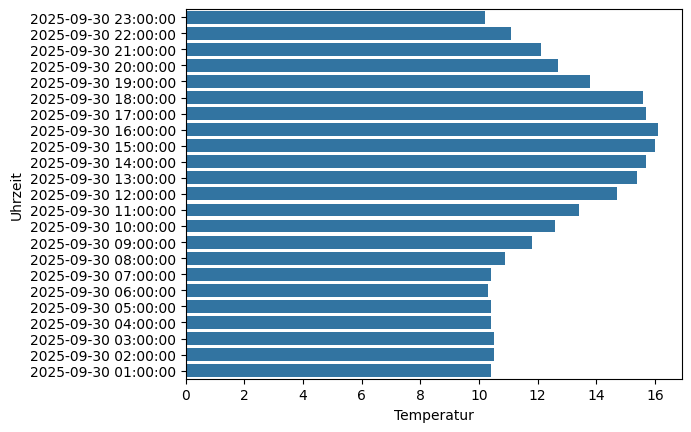

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top20, x="Temperatur", y="Uhrzeit")
plt.show()

In [24]:
query = """SELECT * 
FROM karlsruhe_weather_09_2025
ORDER BY time ASC;"""
df = pd.read_sql_query(query, conn)
df.tail(24)

,time,temp,prcp,snow,wdir,wspd,tsun
696,2025-09-30 00:00:00,10.4,0.0,None,188.0,3.7,0
697,2025-09-30 01:00:00,10.4,0.0,None,179.0,3.7,0
698,2025-09-30 02:00:00,10.5,0.0,None,174.0,3.7,0
699,2025-09-30 03:00:00,10.5,0.0,None,176.0,3.7,0
700,2025-09-30 04:00:00,10.4,0.0,None,163.0,3.7,0
701,2025-09-30 05:00:00,10.4,0.0,None,170.0,3.7,0
702,2025-09-30 06:00:00,10.3,0.0,None,181.0,3.7,0
703,2025-09-30 07:00:00,10.4,0.0,None,201.0,3.7,0
704,2025-09-30 08:00:00,10.9,0.0,None,222.0,3.7,2
705,2025-09-30 09:00:00,11.8,0.0,None,308.0,3.7,5


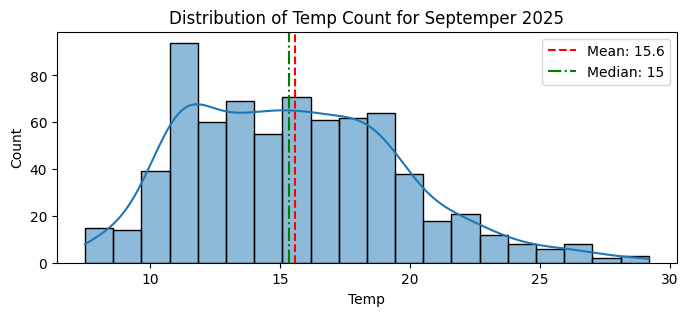

In [25]:
# plot distribution of temp
plt.figure(figsize=(8, 3))
sns.histplot(df['temp'], bins=20, kde=True, color='C0')
mean_temp = df['temp'].mean()
median_temp = df['temp'].median()
plt.axvline(mean_temp, color='red', linestyle='--', label=f"Mean: {mean_temp:.1f}")
plt.axvline(median_temp, color='green', linestyle='-.', label=f"Median: {median_temp:.0f}")
plt.title("Distribution of Temp Count for Septemper 2025")
plt.xlabel("Temp")
plt.ylabel("Count")
plt.legend()
plt.show()

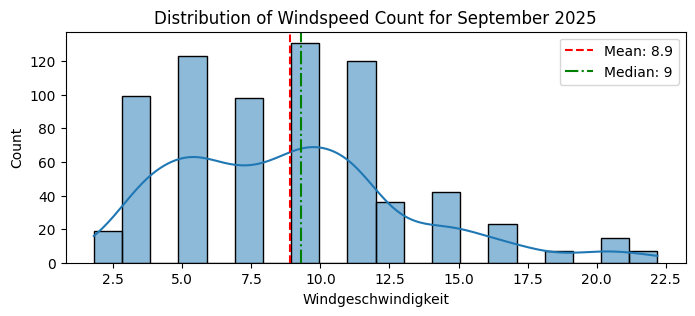

In [26]:
# plot distribution of wspd
plt.figure(figsize=(8, 3))
sns.histplot(df['wspd'], bins=20, kde=True, color='C0')
mean_temp = df['wspd'].mean()
median_temp = df['wspd'].median()
plt.axvline(mean_temp, color='red', linestyle='--', label=f"Mean: {mean_temp:.1f}")
plt.axvline(median_temp, color='green', linestyle='-.', label=f"Median: {median_temp:.0f}")
plt.title("Distribution of Windspeed Count for September 2025")
plt.xlabel("Windgeschwindigkeit")
plt.ylabel("Count")
plt.legend()
plt.show()

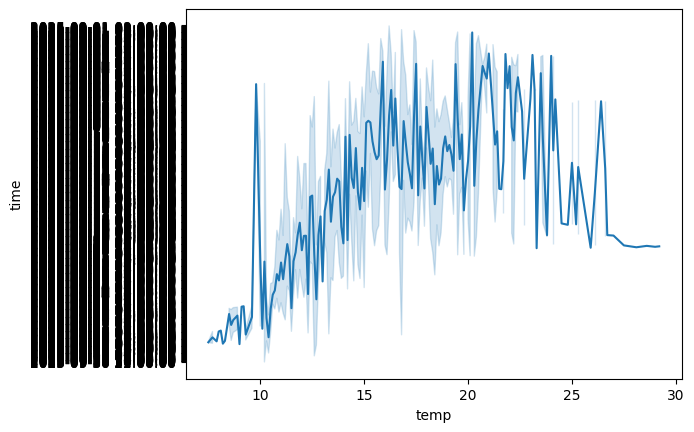

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=df, x="temp", y="time")
#sns.catplot(data=df, x="temp", y="time")
#sns.boxplot(data=df, x="temp", y="time")
#sns.barplot(data=df, x="temp", y="time")
plt.show()

In [34]:
query = '''
SELECT temp as Temperatur, time as Datum
FROM karlsruhe_weather_09_2025
ORDER BY temp ASC, time ASC;'''

df = pd.read_sql_query(query, conn)
df.tail(23)

,Temperatur,Datum
697,24.1,2025-09-20 12:00:00
698,24.2,2025-09-07 14:00:00
699,24.5,2025-09-18 15:00:00
700,24.8,2025-09-18 18:00:00
701,25.0,2025-09-07 19:00:00
702,25.0,2025-09-18 16:00:00
703,25.2,2025-09-18 17:00:00
704,25.3,2025-09-07 15:00:00
705,25.3,2025-09-19 14:00:00
706,25.9,2025-09-20 19:00:00


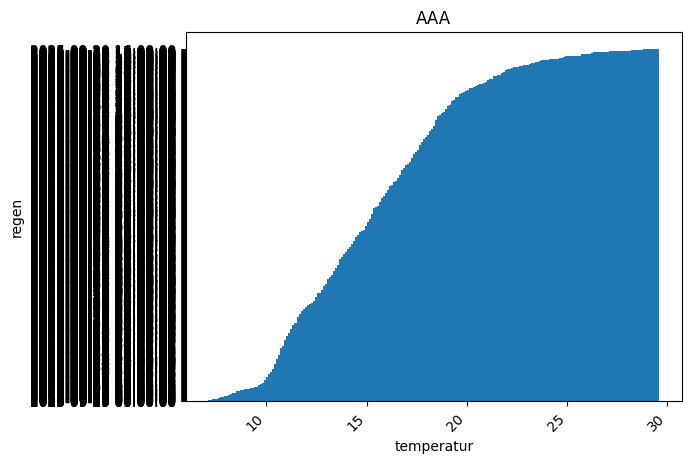

In [36]:
plt.bar(df['Temperatur'], df['Datum'], color='C0')
plt.title("AAA")
plt.xlabel("temperatur")
plt.ylabel("regen")
plt.xticks(rotation=45, ha='right')
plt.show()